## Dataset

In [ ]:
from huggingface_hub import login

login()

c:\Users\Marcin\Desktop\ZPRP\env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
from datasets import load_dataset
battlemaps_dataset = load_dataset("Rpgshit/battlemaps-description-generated")

In [ ]:
battlemaps_dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'short_description', 'description'],
        num_rows: 3965
    })
    validation: Dataset({
        features: ['image', 'short_description', 'description'],
        num_rows: 496
    })
    test: Dataset({
        features: ['image', 'short_description', 'description'],
        num_rows: 496
    })
})

# EmbeddingGemma + MobileViT

In [ ]:
from transformers import MobileViTModel, MobileViTImageProcessor
from sentence_transformers import SentenceTransformer

In [ ]:
PROJECTION_DIM = 256
TEXT_MODEL = 'google/embeddinggemma-300m'
IMAGE_MODEL = "apple/mobilevit-small"

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor

class ProjectionHead(nn.Module):
    def __init__(self, embedding_dim: int, projection_dim: int):
        super().__init__()
        self.projection_dim = projection_dim
        self.projection = nn.Linear(embedding_dim, projection_dim, bias=False)

    def forward(self, x: Tensor) -> Tensor:
        y = self.projection(x)
        z = F.normalize(y, p=2, dim=-1)
        return z

In [ ]:
class TextEncoder(nn.Module):
    def __init__(self, model_name: str, projection_dim: int):
        super().__init__()
        self.backbone = SentenceTransformer(model_name)
        for param in self.backbone.parameters():
            param.requires_grad = False
        hidden_dim = self.backbone.get_sentence_embedding_dimension()
        self.projection_head = ProjectionHead(embedding_dim=hidden_dim, projection_dim=projection_dim)

    def forward(self, input_ids, attention_mask):
        features = {'input_ids': input_ids, 'attention_mask': attention_mask}
        output = self.backbone(features)
        embeddings = output['sentence_embedding']
        return self.projection_head(embeddings)

In [ ]:
class ImageEncoder(nn.Module):
    def __init__(self, model_name: str, projection_dim: int):
        super().__init__()
        self.backbone = MobileViTModel.from_pretrained(model_name)
        for param in self.backbone.parameters():
            param.requires_grad = False
        with torch.no_grad():
            dummy_input = torch.zeros(1, 3, 256, 256)
            dummy_out = self.backbone(dummy_input)
            real_hidden_dim = dummy_out.last_hidden_state.shape[1]
        self.projection_head = ProjectionHead(embedding_dim=real_hidden_dim, projection_dim=projection_dim)

    def forward(self, pixel_values):
        outputs = self.backbone(pixel_values=pixel_values)
        last_hidden_state = outputs.last_hidden_state
        features = last_hidden_state.mean(dim=[-2, -1])
        return self.projection_head(features)

In [ ]:
class CLIPModel(nn.Module):
    def __init__(self,
                 text_model_name=TEXT_MODEL,
                 image_model_name=IMAGE_MODEL,
                 projection_dim=512):
        super().__init__()

        self.text_encoder = TextEncoder(text_model_name, projection_dim)
        self.image_encoder = ImageEncoder(image_model_name, projection_dim)
        self.logit_scale = nn.Parameter(torch.ones([]) * 2.6592)

    def forward(self, batch):
        text_embeddings = self.text_encoder(
            input_ids=batch['input_ids'],
            attention_mask=batch['attention_mask']
        )
        image_input = batch.get('pixel_values', batch.get('image'))
        image_embeddings = self.image_encoder(image_input)

        return text_embeddings, image_embeddings

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = CLIPModel(projection_dim=512).to(device)


dummy_batch = {
    'image': torch.randn(4, 3, 256, 256).to(device),

    'input_ids': torch.randint(0, 1000, (4, 20)).to(device),
    'attention_mask': torch.ones(4, 20).to(device)
}

text_emb, img_emb = model(dummy_batch)

print(f"Wymiar embeddingów tekstu: {text_emb.shape}") # Oczekiwane: [4, 512]
print(f"Wymiar embeddingów obrazu: {img_emb.shape}") # Oczekiwane: [4, 512]
print(f"Czy wektory są znormalizowane? Norma pierwszego: {img_emb[0].norm().item():.4f}") # Oczekiwane: 1.0000

Wymiar embeddingów tekstu: torch.Size([4, 512])
Wymiar embeddingów obrazu: torch.Size([4, 512])
Czy wektory są znormalizowane? Norma pierwszego: 1.0000


In [ ]:
import torch
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, MobileViTImageProcessor
import torch.optim as optim
from tqdm import tqdm

BATCH_SIZE = 16
LR = 1e-4
EPOCHS = 3
device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = AutoTokenizer.from_pretrained("google/embeddinggemma-300m")
image_processor = MobileViTImageProcessor.from_pretrained("apple/mobilevit-small")

def collate_fn(batch):
    images = [item['image'].convert("RGB") for item in batch]
    image_inputs = image_processor(images=images, return_tensors="pt")
    texts = [choice([item['description'], item['short_description']]) for item in batch]

    text_inputs = tokenizer(
        texts,
        padding=True,
        truncation=True,
        return_tensors="pt",
        max_length=128
    )

    return {
        'pixel_values': image_inputs['pixel_values'],
        'input_ids': text_inputs['input_ids'],
        'attention_mask': text_inputs['attention_mask']
    }

# Tworzenie DataLoaderów
train_loader = DataLoader(battlemaps_dataset['train'], batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(battlemaps_dataset['validation'], batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(battlemaps_dataset['test'], batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

In [ ]:
model = CLIPModel(projection_dim=512).to(device)
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)

In [ ]:
def train_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0

    loop = tqdm(loader, desc="Training")
    for batch in loop:
        batch = {k: v.to(device) for k, v in batch.items()}
        optimizer.zero_grad()

        txt_emb, img_emb = model(batch)
        logits = (img_emb @ txt_emb.T) * model.logit_scale.exp()

        labels = torch.arange(logits.size(0)).to(device)

        loss_i = F.cross_entropy(logits, labels)
        loss_t = F.cross_entropy(logits.T, labels)
        loss = (loss_i + loss_t) / 2
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    return total_loss / len(loader)

def evaluate(model, loader):
    model.eval()
    total_loss = 0
    correct_matches = 0
    total_samples = 0

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating"):
            batch = {k: v.to(device) for k, v in batch.items()}

            txt_emb, img_emb = model(batch)

            logits = (img_emb @ txt_emb.T) * model.logit_scale.exp()
            labels = torch.arange(logits.size(0)).to(device)

            loss_i = F.cross_entropy(logits, labels)
            loss_t = F.cross_entropy(logits.T, labels)
            loss = (loss_i + loss_t) / 2
            total_loss += loss.item()
            preds = logits.argmax(dim=1)
            correct_matches += (preds == labels).sum().item()
            total_samples += logits.size(0)

    avg_loss = total_loss / len(loader)
    accuracy = correct_matches / total_samples
    return avg_loss, accuracy

In [ ]:
print("Start treningu...")
for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader, optimizer)
    val_loss, val_acc = evaluate(model, val_loader)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss:  {val_loss:.4f}")
    print(f"Val Accuracy: {val_acc:.2%}")
    print("-" * 30)

Start treningu...


Training:  60%|██████    | 149/248 [05:59<04:04,  2.47s/it, loss=1.81]c:\Users\Marcin\Desktop\ZPRP\env\lib\site-packages\PIL\Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Evaluating: 100%|██████████| 31/31 [01:12<00:00,  2.33s/it]


Epoch 1/3
Train Loss: 2.2135
Val Loss:  1.9083
Val Accuracy: 36.69%
------------------------------


Evaluating: 100%|██████████| 31/31 [01:08<00:00,  2.20s/it]


Epoch 2/3
Train Loss: 1.5816
Val Loss:  1.6679
Val Accuracy: 46.17%
------------------------------


Evaluating: 100%|██████████| 31/31 [01:10<00:00,  2.29s/it]

Epoch 3/3
Train Loss: 1.3179
Val Loss:  1.5625
Val Accuracy: 48.99%
------------------------------


In [ ]:
import torchmetrics

loss_metric = torchmetrics.aggregation.MeanMetric().to(device)
img_acc_metric = torchmetrics.aggregation.MeanMetric().to(device)
cap_acc_metric = torchmetrics.aggregation.MeanMetric().to(device)

model.eval()

print("Rozpoczynam ewaluację z torchmetrics...")

with torch.no_grad():
    for batch in tqdm(test_loader):
        batch = {k: v.to(device) for k, v in batch.items()}

        text_embeddings, image_embeddings = model(batch)

        logit_scale = model.logit_scale.exp()
        logits = (image_embeddings @ text_embeddings.T) * logit_scale
        batch_size = logits.size(0)
        labels = torch.arange(batch_size).to(device)

        loss_i = F.cross_entropy(logits, labels)
        loss_t = F.cross_entropy(logits.T, labels)
        loss = (loss_i + loss_t) / 2

        img_preds = logits.argmax(dim=1)
        img_acc = (img_preds == labels).float().mean()

        txt_preds = logits.argmax(dim=0)
        cap_acc = (txt_preds == labels).float().mean()

        loss_metric.update(loss)
        img_acc_metric.update(img_acc)
        cap_acc_metric.update(cap_acc)

final_loss = loss_metric.compute()
final_img_acc = img_acc_metric.compute()
final_cap_acc = cap_acc_metric.compute()

print("\n" + "="*40)
print(f"Loss: {final_loss:.4f}")
print(f"Image Retrieval Accuracy (Img->Txt): {final_img_acc:.2%}")
print(f"Caption Retrieval Accuracy (Txt->Img): {final_cap_acc:.2%}")
print("="*40)

loss_metric.reset()
img_acc_metric.reset()
cap_acc_metric.reset()

Rozpoczynam ewaluację z torchmetrics...


100%|██████████| 31/31 [01:23<00:00,  2.71s/it]


Loss: 1.5858
Image Retrieval Accuracy (Img->Txt): 52.02%
Caption Retrieval Accuracy (Txt->Img): 48.59%


In [ ]:
import torch
import matplotlib.pyplot as plt
import math
from tqdm import tqdm

class ImageSearchEngine:
    def __init__(self, model, dataset, image_processor, tokenizer, device):
        self.model = model
        self.dataset = dataset
        self.image_processor = image_processor
        self.tokenizer = tokenizer
        self.device = device
        self.image_embeddings = None

    def build_index(self, batch_size=32):
        self.model.eval()
        embeddings_list = []

        print(f"Tworzenie indeksu dla {len(self.dataset)} obrazów...")

        for i in tqdm(range(0, len(self.dataset), batch_size)):
            batch_items = self.dataset[i : i + batch_size]
            raw_images = batch_items['image']

            images_rgb = [img.convert("RGB") for img in raw_images]

            inputs = self.image_processor(images=images_rgb, return_tensors="pt")
            pixel_values = inputs['pixel_values'].to(self.device)

            with torch.no_grad():
                img_emb = self.model.image_encoder(pixel_values)
                embeddings_list.append(img_emb.cpu())

        self.image_embeddings = torch.cat(embeddings_list)
        print("Indeks gotowy!")

    def search(self, query_text, top_k=5):
        if self.image_embeddings is None:
            raise ValueError("Najpierw uruchom metodę .build_index()!")

        self.model.eval()
        with torch.no_grad():
            inputs = self.tokenizer([query_text], padding=True, truncation=True, return_tensors="pt")
            input_ids = inputs['input_ids'].to(self.device)
            attention_mask = inputs['attention_mask'].to(self.device)

            query_emb = self.model.text_encoder(input_ids, attention_mask)

            index_device = self.image_embeddings.to(self.device)
            scores = (query_emb @ index_device.T).squeeze(0)

            top_scores, top_indices = scores.topk(top_k)

            return top_scores.cpu().numpy(), top_indices.cpu().numpy()

    def visualize_search(self, query_text, top_k=3):
        scores, indices = self.search(query_text, top_k)

        print(f"\nWyniki dla zapytania: '{query_text}'")

        plt.figure(figsize=(15, 5))

        for i, (score, idx) in enumerate(zip(scores, indices)):
            idx = int(idx)
            image = self.dataset[idx]['image']
            description = self.dataset[idx]['short_description']

            ax = plt.subplot(1, top_k, i + 1)
            ax.imshow(image)
            ax.axis("off")
            ax.set_title(f"Score: {score:.3f}\n{description[:30]}...", fontsize=10)

        plt.show()

search_engine = ImageSearchEngine(
    model=model,
    dataset=battlemaps_dataset['test'],
    image_processor=image_processor,
    tokenizer=tokenizer,
    device=device
)

search_engine.build_index(batch_size=32)

Tworzenie indeksu dla 496 obrazów...


100%|██████████| 16/16 [01:22<00:00,  5.14s/it]

Indeks gotowy!



Wyniki dla zapytania: 'dungeon interior trees'


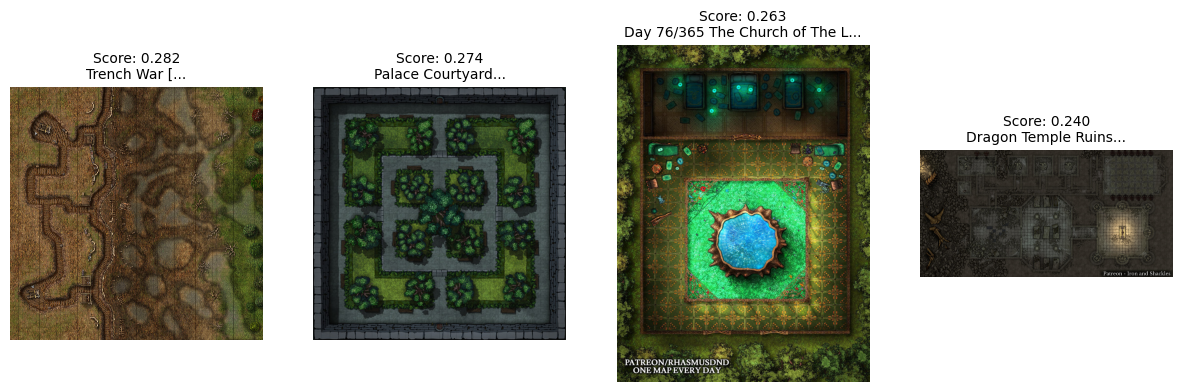

In [ ]:

zaptanie = "dungeon interior trees"
search_engine.visualize_search(zaptanie, top_k=4)


Wyniki dla zapytania: 'Dark cave with threasure'


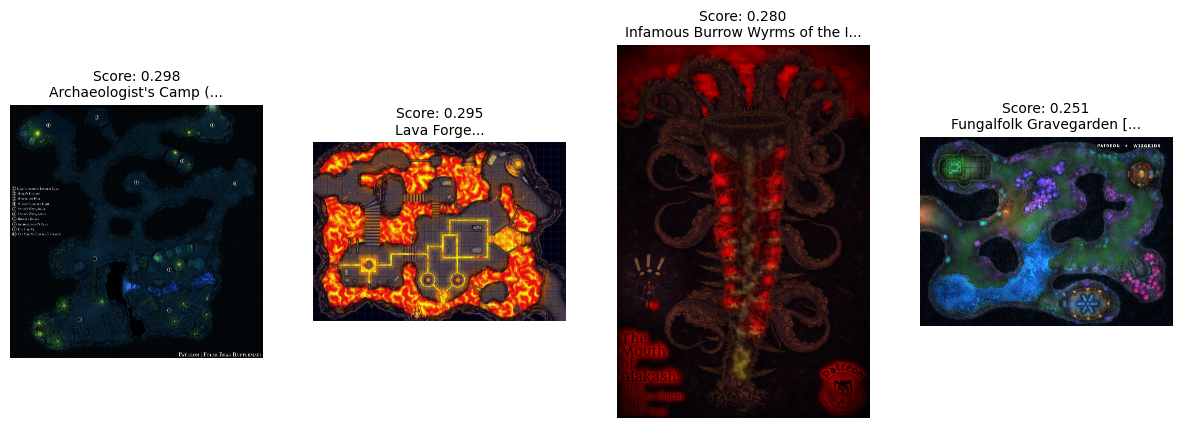

In [ ]:
zaptanie = "Dark cave with threasure"
search_engine.visualize_search(zaptanie, top_k=4)


Wyniki dla zapytania: 'Big castle'


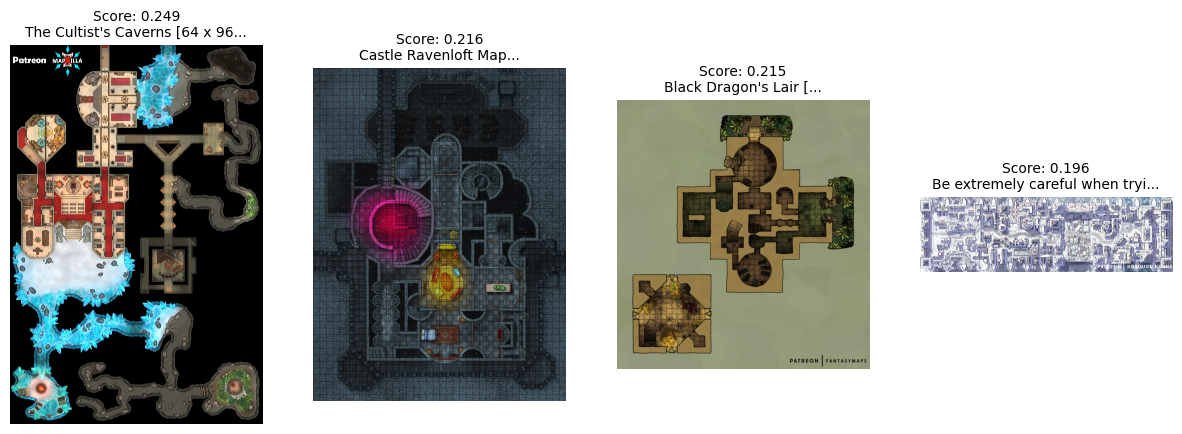

In [ ]:
zaptanie = "Big castle"
search_engine.visualize_search(zaptanie, top_k=4)


Wyniki dla zapytania: 'Forest, path, stones, river'


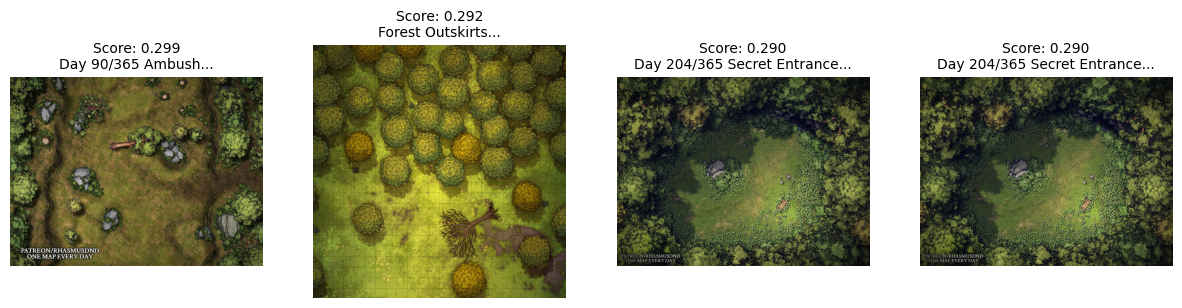

In [ ]:
zaptanie = "Forest, path, stones, river"
search_engine.visualize_search(zaptanie, top_k=4)